In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [2]:
warnings.filterwarnings("ignore")

In [3]:
veri = pd.read_csv("data/heart_statlog_cleveland_hungary_final.csv")

## **Veri Seti Nitelik Açıklamaları**

### **1. `age`**

- **Açıklama:** Hastanın yaşı (yıl cinsinden).
- **Veri Tipi:** Numerik

### **2. `sex`**

- Açıklama: 

  Hastanın cinsiyeti.

  - **1:** Erkek
  - **0:** Kadın

- **Veri Tipi:** Binary (İkili)

### **3. `chest pain type`**

- Açıklama: 

  Göğüs ağrısı tipi.

  - **1:** Tipik anjina (angina)
  - **2:** Atipik anjina
  - **3:** Non-anjinal ağrı
  - **4:** Asemptomatik (ağrı yok)

- **Veri Tipi:** Nominal (Kategorik)

### **4. `resting bp s`**

- **Açıklama:** Hastanın dinlenme kan basıncı (mm Hg cinsinden).
- **Veri Tipi:** Numerik

### **5. `cholesterol`**

- **Açıklama:** Serum kolesterol değeri (mg/dl cinsinden).
- **Veri Tipi:** Numerik

### **6. `fasting blood sugar`**

- Açıklama: 

  Açlık kan şekeri (> 120 mg/dl olup olmadığı).

  - **1:** Evet (kan şekeri > 120 mg/dl)
  - **0:** Hayır (kan şekeri <= 120 mg/dl)

- **Veri Tipi:** Binary (İkili)

### **7. `resting ecg`**

- Açıklama: 

  Dinlenme elektrokardiyogram (ECG) sonuçları.

  - **0:** Normal
  - **1:** ST-T dalgası anormalliği (T dalga terslenmeleri ve/veya ST yükselmesi veya depresyonu > 0.05 mV)
  - **2:** Muhtemel veya kesin sol ventriküler hipertrofi (Estes kriterlerine göre)

- **Veri Tipi:** Nominal (Kategorik)

### **8. `max heart rate`**

- **Açıklama:** Ulaşılan maksimum kalp hızı.
- **Veri Tipi:** Numerik

### **9. `exercise angina`**

- Açıklama: 

  Egzersiz ile indüklenen anjina (göğüs ağrısı).

  - **1:** Evet
  - **0:** Hayır

- **Veri Tipi:** Binary (İkili)

### **10. `oldpeak`**

- **Açıklama:** Egzersizle indüklenen ST segment depresyonu (depression).
- **Veri Tipi:** Numerik

### **11. `ST slope`**

- Açıklama: 

  Egzersizdeki ST segmentinin eğimi.

  - **1:** Yukarı doğru (upsloping)
  - **2:** Düz (flat)
  - **3:** Aşağı doğru (downsloping)

- **Veri Tipi:** Nominal (Kategorik)

### **12. `target`**

- Açıklama: 

  Kalp hastalığı durumu.

  - **1:** Kalp hastalığı var
  - **0:** Normal

- **Veri Tipi:** Binary (İkili)

In [4]:
display(veri)

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


# ÖNİŞLEME

## **1. Adım: Eksik Değer Analizi**

### **Teori**

Eksik değerler, veri setinde bulunan boş veya tanımlanmamış hücrelerdir. Bu değerler, modelin performansını olumsuz etkileyebilir. Eksik değerlerin tespiti ve ele alınması, veri önişleme sürecinin önemli bir parçasıdır.

- **Eksik değerlerin nedenleri:**
  - İnsan hatası
  - Sensör veya cihaz hataları
  - Veri toplama süreçlerindeki eksiklikler
- **Çözüm yöntemleri:**
  - Eksik değerleri doldurma (ortalama, medyan, mod)
  - Eksik değer içeren satırları silme
  - Makine öğrenmesi algoritmaları ile tahmin etme

In [5]:
# Eksik değerlerin kontrolü
missing_values = veri.isnull().sum()
print("Eksik Değerler:\n", missing_values)

# Eksik değer oranlarını hesaplama
missing_ratio = veri.isnull().mean() * 100
print("\nEksik Değer Oranları (%):\n", missing_ratio)

# Eksik değerleri doldurma (örneğin ortalama ile)
#veri.fillna(df.mean(), inplace=True)

# Eksik değer içeren satırları silme (isteğe bağlı)
# veri.dropna(inplace=True)

Eksik Değerler:
 age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Eksik Değer Oranları (%):
 age                    0.0
sex                    0.0
chest pain type        0.0
resting bp s           0.0
cholesterol            0.0
fasting blood sugar    0.0
resting ecg            0.0
max heart rate         0.0
exercise angina        0.0
oldpeak                0.0
ST slope               0.0
target                 0.0
dtype: float64


## **2. Adım: Tekrar Eden Veri (Duplicate) Analizi**

### **Teori**

Tekrar eden veriler, veri setinde aynı bilgileri içeren birden fazla satır anlamına gelir. Bu durum, modelin eğitimi sırasında yanlılığa neden olabilir. Tekrar eden verilerin tespit edilmesi ve kaldırılması önemlidir.

- Çözüm yöntemleri:
  - Tüm sütunlara göre tekrar eden satırları silme
  - Belirli sütunlara göre tekrar eden satırları silme

In [6]:
# Tekrar eden verilerin kontrolü
print("Veri Seti Boyutu:", veri.shape)
duplicates = veri.duplicated()
print("Tekrar Eden Veri Sayısı:", duplicates.sum())

# Tekrar eden verileri silme
veri.drop_duplicates(inplace=True)

# Sonuç kontrolü
print("Tekrar Eden Veri Silindikten Sonra Veri Seti Boyutu:", veri.shape)

Veri Seti Boyutu: (1190, 12)
Tekrar Eden Veri Sayısı: 272
Tekrar Eden Veri Silindikten Sonra Veri Seti Boyutu: (918, 12)


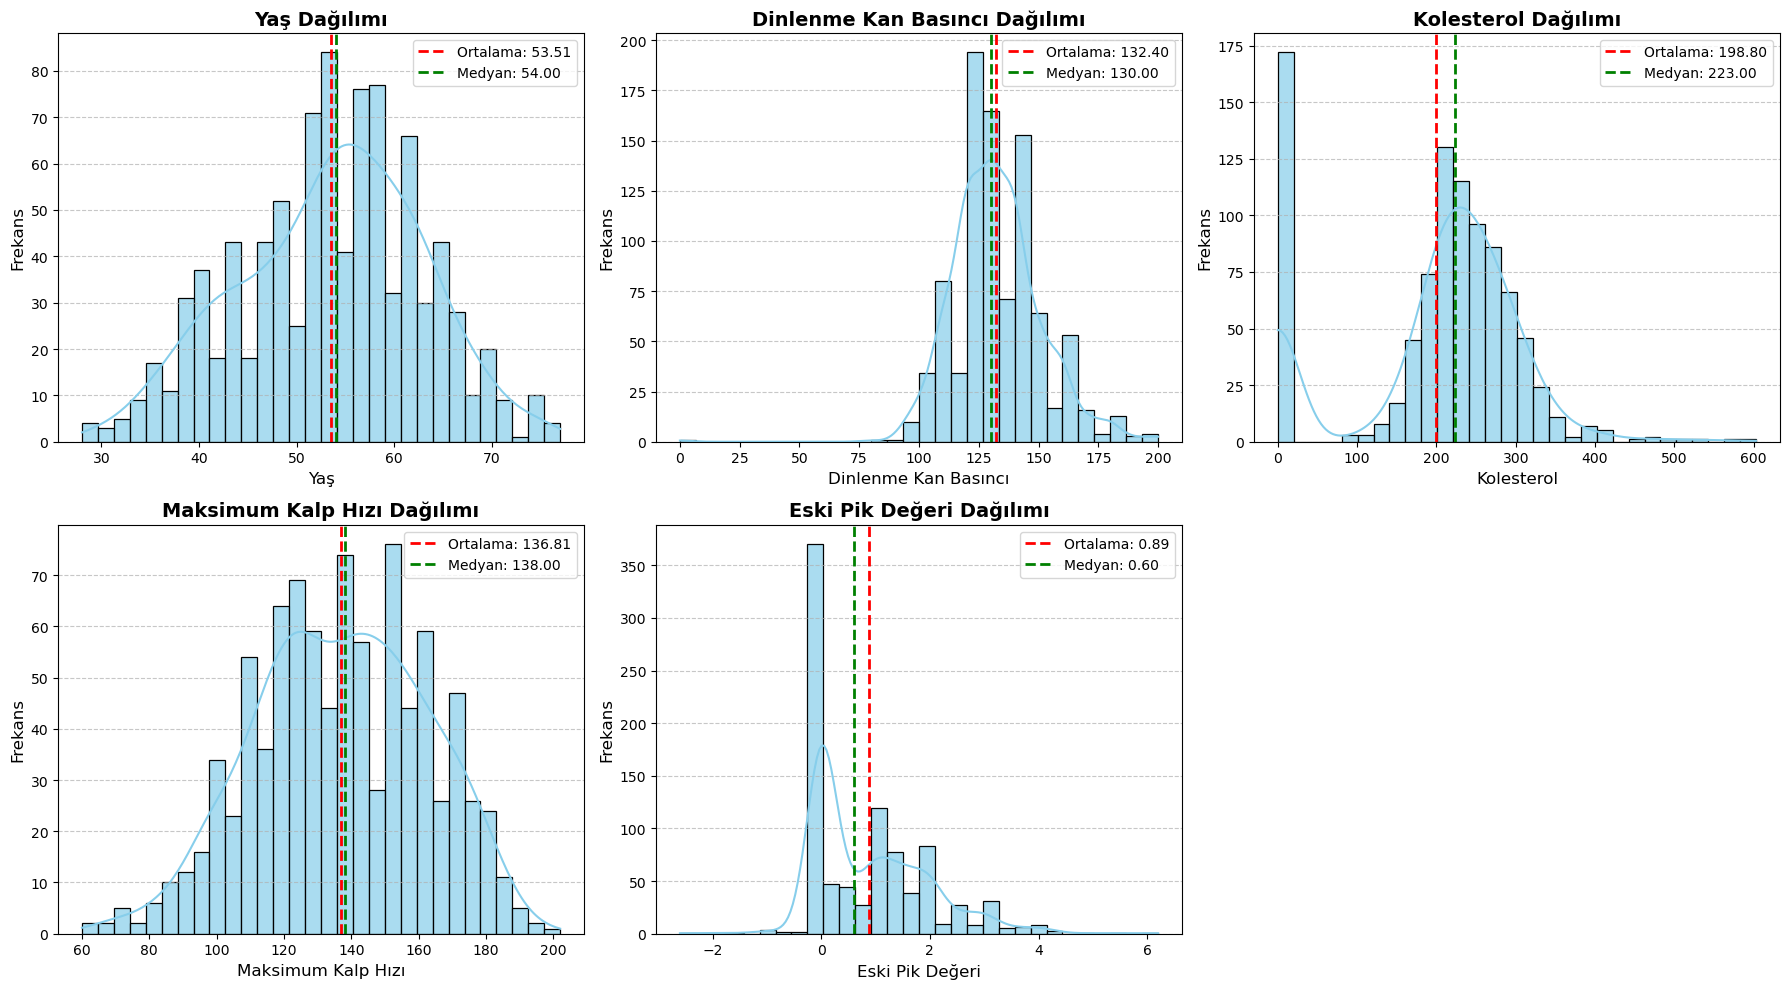

In [7]:
# Numerik sütunların listesi
numerical_columns = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

# Çeviri sözlüğü (Türkçe başlıklar için)
column_translations = {
    'age': 'Yaş',
    'resting bp s': 'Dinlenme Kan Basıncı',
    'cholesterol': 'Kolesterol',
    'max heart rate': 'Maksimum Kalp Hızı',
    'oldpeak': 'Eski Pik Değeri'
}

# Grafikleri 2x3 boyutunda oluştur (2 satır, 3 sütun)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Düz bir diziye dönüştürme

for i, col in enumerate(numerical_columns):
    # Histogram ve Kernel Density Estimate (KDE) grafiği
    sns.histplot(data=veri, x=col, kde=True, bins=30, ax=axes[i], color="skyblue", edgecolor="black", alpha=0.7)
    
    # Ortalama ve medyan değerlerini hesaplama
    mean_val = veri[col].mean()
    median_val = veri[col].median()
    
    # Ortalama ve medyan değerlerini grafiğe ekleme
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Ortalama: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Medyan: {median_val:.2f}')
    
    # Başlık ve etiketler
    axes[i].set_title(f"{column_translations[col]} Dağılımı", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(column_translations[col], fontsize=12)
    axes[i].set_ylabel("Frekans", fontsize=12)
    
    # Legend eklemek
    axes[i].legend(fontsize=10)
    
    # Grid eklemek
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Boş alanları temizleme
if len(numerical_columns) < len(axes):
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])

# Genel grafik ayarları
plt.tight_layout()
plt.show()

## **Grafiğin Makine Öğrenmesi İle İlgili Yorumları ve Gerçekleştirilecek Adımlar**

### **1. Yaş Dağılımı**

- **Yorum:**
  - Yaş dağılımı normal bir şekilde görünüyor, ortalaması ve medyanı yaklaşık **53-54** civarı.
  - Değerlerin çoğunluğu **40 ila 60 yaş aralığında** toplanmıştır.
  - Düşük (30'lar) ve yüksek yaşlarda (70'ler ve üstü) veriler az.
- **Makine Öğrenmesi İçin Gereken Adımlar:**
  1. Aykırı Değer Kontrolü:
     - IQR veya z-score yöntemleriyle aykırı değerler tespit edilip gerekirse düzeltme
     - Eğer aykırı değerler varsa, silme veya sınırlama gibi işlemler uygulama
  2. Ölçeklendirme:
     - `StandardScaler` veya `MinMaxScaler` kullanarak yaş değişkenini ölçeklendirme
  3. Feature Engineering:
     - Yaşı kategorik değerlere dönüştürme (örneğin, gençlik, orta yaş, yaşlılık).
     - Yaşı maksimum kalp hızıyla ilişkilendirmek için yeni bir özellik oluşturabilirsiniz (`age * max_heart_rate`).

#### **1. IQR Yöntemi ile Aykırı Değer Tespiti**

**IQR Hesaplama Adımları:**

- `Q1` (1. çeyrek): Verinin %25'lik kısmını temsil eder.
- `Q3` (3. çeyrek): Verinin %75'lik kısmını temsil eder.
- `IQR = Q3 - Q1`
- Alt sınır: `Q1 - 1.5 * IQR`
- Üst sınır: `Q3 + 1.5 * IQR`

Bu alt ve üst sınırların dışına çıkan değerler aykırı değer olarak kabul edilir.

#### **Uygulama Adımları:**

1. Yaş değişkeninin çeyreklik değerlerini hesaplayın (`Q1`, `Q3`).
2. IQR değerini hesaplayın.
3. Alt ve üst sınırları belirleyin.
4. Sınırların dışında kalan yaş değerlerini tespit edin.
5. Gerekiyorsa, bu değerleri silin veya sınırlayarak düzeltin.

In [8]:
# IQR ile Aykırı Değer Tespiti
# Yaş sütununu seçme
yas = veri['age']

# IQR hesaplama
Q1 = yas.quantile(0.25)
Q3 = yas.quantile(0.75)
IQR = Q3 - Q1

# Alt ve üst sınırlar
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Aykırı değerleri tespit etme
aykiri_yaslar = yas[(yas < alt_sinir) | (yas > ust_sinir)]

# Aykırı değerleri yazdırma
print("Aykırı Yaş Değerleri:")
print(aykiri_yaslar)

# Aykırı değerleri sınırlama (örneğin alt/üst sınırlara çekme)
yas_duzeltilmis = yas.clip(lower=alt_sinir, upper=ust_sinir)

# Düzeltme sonrası veriyi güncelleme
veri['age'] = yas_duzeltilmis

# Güncellenmiş veriyi kaydetme
#veri.to_csv("duzeltilmis_veri.csv", index=False)

Aykırı Yaş Değerleri:
Series([], Name: age, dtype: int64)


### **2. Z-Score Yöntemi ile Aykırı Değer Tespiti**

**Z-Score Hesaplama Adımları:**

- Z-score, bir değerin ortalamadan kaç standart sapma uzakta olduğunu gösterir.
- Genellikle |z| > 3 olan değerler aykırı olarak kabul edilir.

#### **Uygulama Adımları:**

1. Yaş değişkeninin ortalamasını ve standart sapmasını hesaplayın.
2. Her bir yaş değeri için z-score'u hesaplayın.
3. |z| > 3 olan değerleri aykırı olarak işaretleyin.
4. Gerekiyorsa, bu değerleri silin veya değiştirin.

In [9]:
from scipy.stats import zscore
# Z-Score ile Aykırı Değer Tespiti)
# Z-score hesaplama
yas_zscore = zscore(yas)

# Aykırı değerleri tespit etme (|z| > 3)
aykiri_yaslar_z = yas[abs(yas_zscore) > 3]

# Aykırı değerleri yazdırma
print("Aykırı Yaş Değerleri (Z-Score):")
print(aykiri_yaslar_z)

# Aykırı değerleri sınırlama (örneğin alt/üst sınırlara çekme)
yas_duzeltilmis_z = yas.clip(lower=yas.mean() - 3*yas.std(), upper=yas.mean() + 3*yas.std())

# Düzeltme sonrası veriyi güncelleme
veri['age'] = yas_duzeltilmis_z

Aykırı Yaş Değerleri (Z-Score):
Series([], Name: age, dtype: int64)


**IQR Yöntemi:**
   - IQR, özellikle verinin dağılımı normal olmadığında daha güvenilir sonuçlar verir.
   - Alt ve üst sınırların dışında kalan yaş değerleri aykırı olarak işaretlenir.
     
**Z-Score Yöntemi:**
   - Z-score, verinin normal dağıldığı varsayımına dayanır.
   - |z| > 3 olan değerler genellikle aykırı olarak kabul edilir.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
veri['age_standardized'] = scaler.fit_transform(veri[['age']])

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
veri['age_minmax_scaled'] = scaler.fit_transform(veri[['age']])

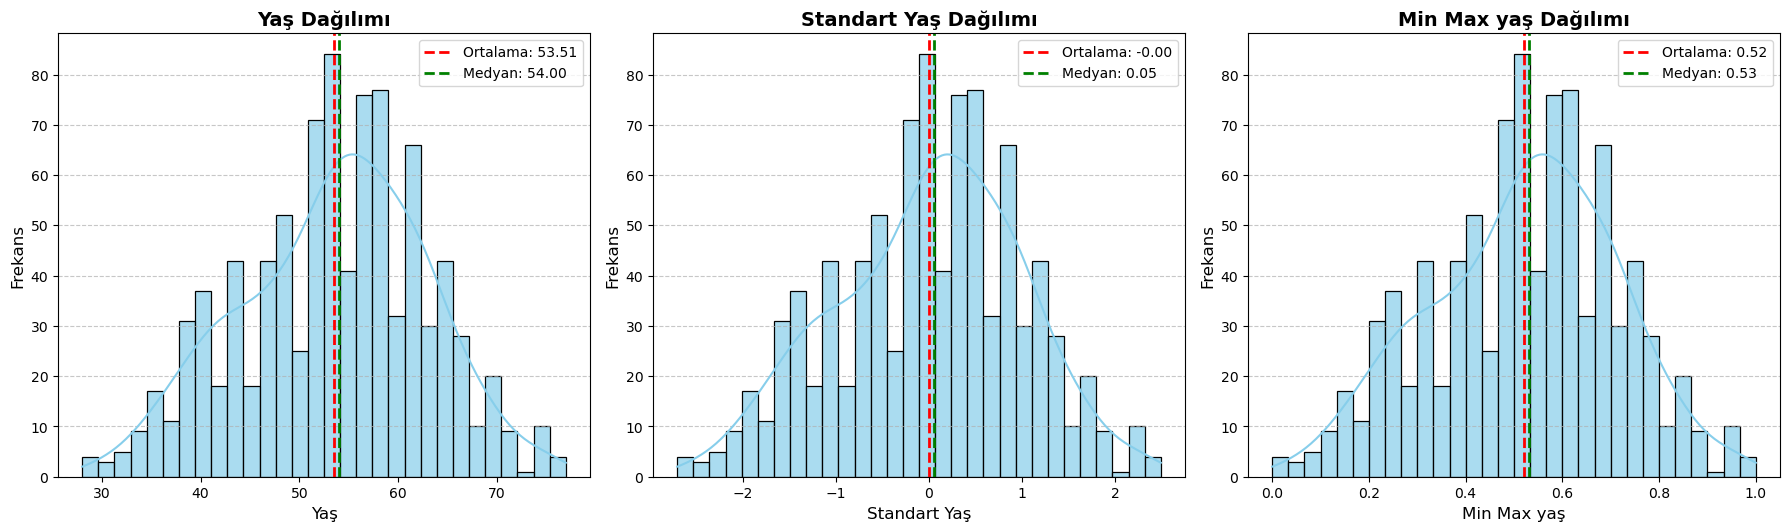

In [15]:
#Numerik sütunların listesi
numerical_columns = ['age', 'age_standardized','age_minmax_scaled']

# Çeviri sözlüğü (Türkçe başlıklar için)
column_translations = {
    'age': 'Yaş',
    'age_standardized': "Standart Yaş",
    'age_minmax_scaled': "Min Max yaş",
    'resting bp s': 'Dinlenme Kan Basıncı',
    'cholesterol': 'Kolesterol',
    'max heart rate': 'Maksimum Kalp Hızı',
    'oldpeak': 'Eski Pik Değeri'
}

# Grafikleri 2x3 boyutunda oluştur (2 satır, 3 sütun)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Düz bir diziye dönüştürme

for i, col in enumerate(numerical_columns):
    # Histogram ve Kernel Density Estimate (KDE) grafiği
    sns.histplot(data=veri, x=col, kde=True, bins=30, ax=axes[i], color="skyblue", edgecolor="black", alpha=0.7)
    
    # Ortalama ve medyan değerlerini hesaplama
    mean_val = veri[col].mean()
    median_val = veri[col].median()
    
    # Ortalama ve medyan değerlerini grafiğe ekleme
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Ortalama: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Medyan: {median_val:.2f}')
    
    # Başlık ve etiketler
    axes[i].set_title(f"{column_translations[col]} Dağılımı", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(column_translations[col], fontsize=12)
    axes[i].set_ylabel("Frekans", fontsize=12)
    
    # Legend eklemek
    axes[i].legend(fontsize=10)
    
    # Grid eklemek
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Boş alanları temizleme
if len(numerical_columns) < len(axes):
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])

# Genel grafik ayarları
plt.tight_layout()
plt.show()

In [14]:
veri

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,age_standardized,age_minmax_scaled
0,40,1,2,140,289,0,0,172,0,0.0,1,0,-1.433140,0.244898
1,49,0,3,160,180,0,0,156,0,1.0,2,1,-0.478484,0.428571
2,37,1,2,130,283,0,1,98,0,0.0,1,0,-1.751359,0.183673
3,48,0,4,138,214,0,0,108,1,1.5,2,1,-0.584556,0.408163
4,54,1,3,150,195,0,0,122,0,0.0,1,0,0.051881,0.530612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1,-0.902775,0.346939
1186,68,1,4,144,193,1,0,141,0,3.4,2,1,1.536902,0.816327
1187,57,1,4,130,131,0,0,115,1,1.2,2,1,0.370100,0.591837
1188,57,0,2,130,236,0,2,174,0,0.0,2,1,0.370100,0.591837


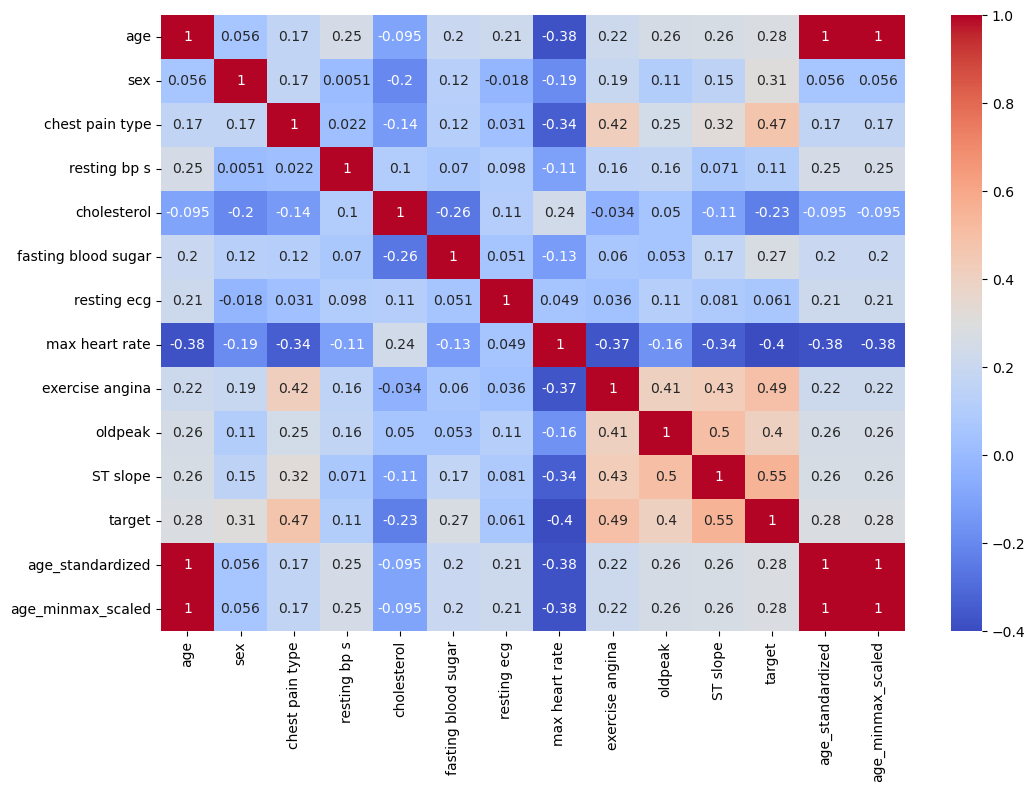

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(veri.corr(), annot=True, cmap='coolwarm')
plt.show()

In [17]:
# Yaş kategorileri tanımlama
bins = [0, 30, 50, 70, float('inf')]  # Sınır değerleri belirleyin
labels = ['Genç', 'Orta Yaş', 'Yaşlı', 'Çok Yaşlı']  # Kategori isimleri

# Yeni bir sütun oluşturarak yaşları kategorilere ayırma
veri['age_category'] = pd.cut(veri['age'], bins=bins, labels=labels)

# Sonucu görüntüleme
display(veri[['age', 'age_category']].head())

,age,age_category
0,40,Orta Yaş
1,49,Orta Yaş
2,37,Orta Yaş
3,48,Orta Yaş
4,54,Yaşlı


In [18]:
# Yeni bir özellik oluştur: age * max_heart_rate
veri['age_max_heart_rate'] = veri['age'] * veri['max heart rate']

# Alternatif olarak, normalize edilmiş bir özellik de oluşturulabilir:
veri['age_heart_rate_ratio'] = veri['age'] / veri['max heart rate']

# Sonucu görüntüleme
display(veri[['age', 'max heart rate', 'age_max_heart_rate', 'age_heart_rate_ratio']].head())

,age,max heart rate,age_max_heart_rate,age_heart_rate_ratio
0,40,172,6880,0.232558
1,49,156,7644,0.314103
2,37,98,3626,0.377551
3,48,108,5184,0.444444
4,54,122,6588,0.442623


In [ ]:
veri.to_csv("age_islenmis.csv")